# Black–Scholes from first principles

**pyportfolios.com** · [/research/black-scholes-from-first-principles](https://pyportfolios.com/research/black-scholes-from-first-principles) · QQQ 2017–2024 · NumPy · Pandas · SciPy · scikit-learn · yfinance

Black–Scholes is the answer to one question: *what must an option cost if you could
hedge it perfectly?* In this notebook we make every number in that answer real:

1. test the model's "constant σ" assumption against QQQ's rolling realised vol,
2. price a real ATM 1-year QQQ call — spot, vol and risk-free rate all observed,
3. compute all five Greeks and verify put–call parity,
4. draw the call price curve against intrinsic value, and
5. build the volatility smile the flat-σ model cannot make, from a 2-state
   mixture calibrated to QQQ's actual returns (seed 42).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy import stats
from scipy.optimize import brentq
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42

## 1 · Is σ constant? Ask the data

The model assumes one volatility, forever. QQQ's rolling 1-year realised vol is the
cheapest possible test of that assumption — download the closes, roll a standard
deviation, annualise.

realised 1y vol: min 10.4%  max 36.3%  latest 18.0%


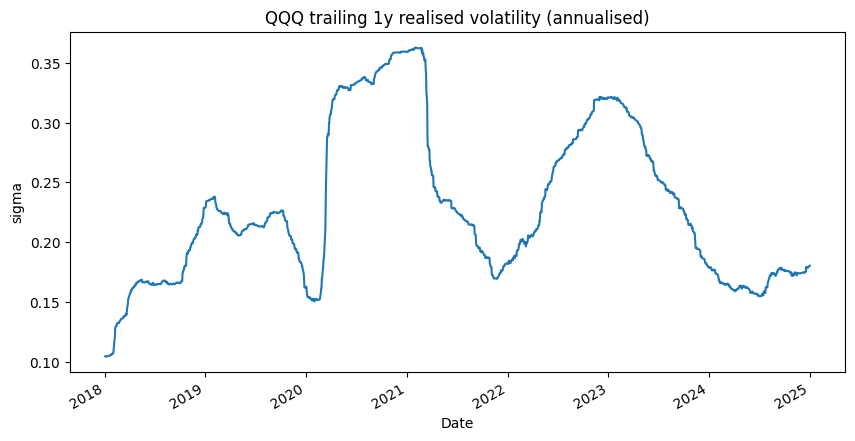

In [2]:
px = yf.download("QQQ", start="2017-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"].squeeze().dropna()
logret = np.log(px / px.shift(1)).dropna()

roll252 = (logret.rolling(252).std(ddof=1) * np.sqrt(252)).dropna()
roll252.plot(title="QQQ trailing 1y realised volatility (annualised)")
plt.ylabel("sigma");

print(f"realised 1y vol: min {roll252.min():.1%}  max {roll252.max():.1%}  "
      f"latest {roll252.iloc[-1]:.1%}")

So the "constant" parameter roughly tripled inside one sample. Keep that in mind —
it is exactly the crack the smile (section 5) grows out of.

## 2 · A real contract

We price a 1-year at-the-money call on QQQ using only observed inputs: the last
close as spot, the nearest listed strike, trailing 1y realised vol as σ, and the
13-week T-bill yield (^IRX, quoted in percent) as the risk-free rate.

In [3]:
irx = yf.download("^IRX", start="2024-12-01", end="2025-01-01",
                  auto_adjust=True, progress=False)["Close"].squeeze().dropna()

S0    = float(px.iloc[-1])
K     = round(S0 / 5) * 5          # nearest $5 strike
T     = 1.0
r     = float(irx.iloc[-1]) / 100  # ^IRX is in percent
sigma = float(roll252.iloc[-1])

print(f"S0 = {S0:.2f}   K = {K:.0f}   T = {T}   r = {r:.4f}   sigma = {sigma:.4f}")

S0 = 507.45   K = 505   T = 1.0   r = 0.0421   sigma = 0.1804


## 3 · Price and Greeks

Direct transcription of the closed form. The Greeks are the analytic derivatives of
the price, so they come almost for free.

In [4]:
def bs_price(S, K, T, r, sigma, kind="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if kind == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf = norm.pdf(d1)
    return {
        "delta": norm.cdf(d1),
        "gamma": pdf / (S * sigma * np.sqrt(T)),
        "vega":  S * pdf * np.sqrt(T) / 100,
        "theta": (-(S * pdf * sigma) / (2 * np.sqrt(T))
                  - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365,
        "rho":   K * T * np.exp(-r * T) * norm.cdf(d2) / 100,
    }

C = bs_price(S0, K, T, r, sigma, "call")
P = bs_price(S0, K, T, r, sigma, "put")
print(f"call = {C:.2f}   put = {P:.2f}")
for k, v in bs_greeks(S0, K, T, r, sigma).items():
    print(f"{k:>6}: {v: .4f}")

# put-call parity: C - P = S - K e^{-rT}, to machine precision
assert abs((C - P) - (S0 - K * np.exp(-r * T))) < 1e-8

call = 48.45   put = 25.19
 delta:  0.6370
 gamma:  0.0041
  vega:  1.9039
 theta: -0.0787
   rho:  2.7478


## 4 · The price curve

Plot C(S) across spot against the hockey-stick intrinsic value. The vertical gap
between the two is time value; delta is the slope of the smooth curve.

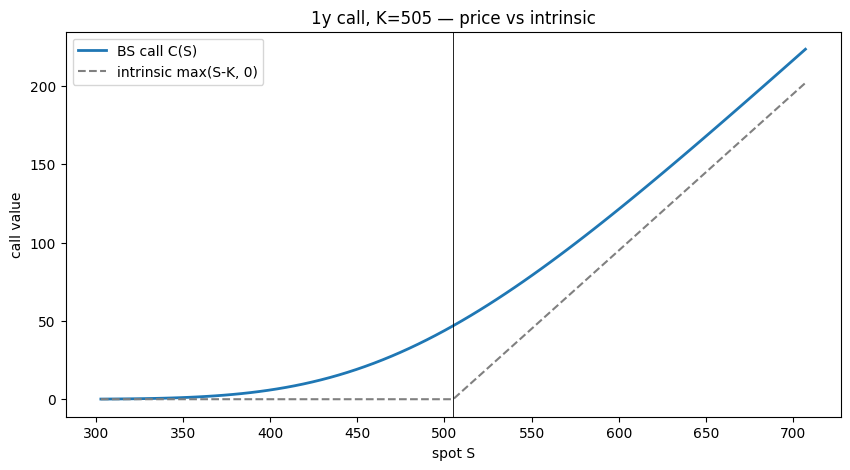

In [5]:
s_grid = np.linspace(0.6 * K, 1.4 * K, 81)
plt.plot(s_grid, bs_price(s_grid, K, T, r, sigma), lw=2, label="BS call C(S)")
plt.plot(s_grid, np.maximum(s_grid - K, 0), "--", lw=1.5, color="grey",
         label="intrinsic max(S-K, 0)")
plt.axvline(K, color="k", lw=0.6)
plt.xlabel("spot S"); plt.ylabel("call value")
plt.title(f"1y call, K={K:.0f} — price vs intrinsic"); plt.legend();
plt.show()

## 5 · The smile the model cannot make

If volatility really were one number, every strike would imply the same σ. But QQQ's
returns are not one lognormal — a 2-state Gaussian mixture (calm + stress) fits them
far better. Price calls under that mixture (a weight-average of BS prices is exact
for a mixture of lognormals), then invert each price back through Black–Scholes:
the implied σ is no longer flat. That U-shape is the smile, generated here entirely
from real-return calibration.

calm  : weight 0.77, sigma 14.4%
stress: weight 0.23, sigma 39.0%
excess kurtosis of QQQ returns: 6.78 (normal = 0)


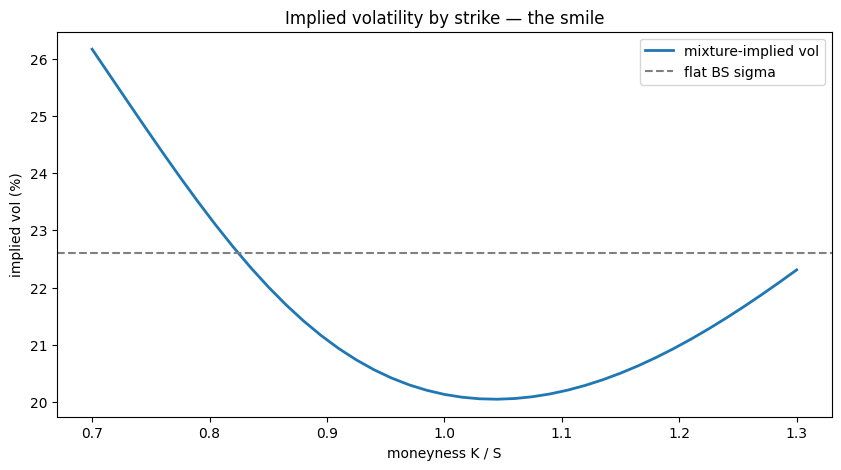

In [6]:
gm = GaussianMixture(n_components=2, random_state=SEED, n_init=5)
gm.fit(logret.values.reshape(-1, 1))
w     = gm.weights_.ravel()
sig_d = np.sqrt(gm.covariances_.ravel())
order = np.argsort(sig_d)
w, sig_a = w[order], sig_d[order] * np.sqrt(252)

print(f"calm  : weight {w[0]:.2f}, sigma {sig_a[0]:.1%}")
print(f"stress: weight {w[1]:.2f}, sigma {sig_a[1]:.1%}")
print(f"excess kurtosis of QQQ returns: {stats.kurtosis(logret):.2f} (normal = 0)")

def mix_call(strike):
    return sum(wi * bs_price(S0, strike, T, r, si) for wi, si in zip(w, sig_a))

m_grid = np.linspace(0.70, 1.30, 41)
iv = [brentq(lambda v: bs_price(S0, m * S0, T, r, v) - mix_call(m * S0), 1e-4, 3.0)
      for m in m_grid]

blend = np.sqrt(np.sum(w * sig_a**2))
plt.plot(m_grid, np.array(iv) * 100, lw=2, label="mixture-implied vol")
plt.axhline(blend * 100, ls="--", color="grey", label="flat BS sigma")
plt.xlabel("moneyness K / S"); plt.ylabel("implied vol (%)")
plt.title("Implied volatility by strike — the smile"); plt.legend();
plt.show()

## Takeaways

- Every input to Black–Scholes is observable except σ — and σ is the one the data
  refuses to hold constant.
- Price, all five Greeks, and put–call parity: ~20 lines of NumPy.
- Two vol regimes are enough to bend the flat line into a smile. Real markets have
  more than two, which is why real smiles are steeper still — especially the put wing.
- The formula survives its own falsification by becoming a *quoting convention*:
  traders quote implied vol precisely because BS is an invertible translation.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*